Exploratory Data Analysis

This notebook explores the cleaned Amazon Electronics reviews dataset. The goal is to understand the characteristics of the data and determine whether it is suitable for sentiment classification using BERT and review summarization using BART.

In [1]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the processed dataset
df = pd.read_csv("../data/processed/preprocessed_reviews.csv")

In [3]:
# First few rows of the dataset
df.head()

,parent_asin,review_title,text,rating,helpful_vote,verified_purchase,product_title,main_category,average_rating,rating_number,review,sentiment
0,B0995JS7K9,These caneras work great!,Great value,5,0,True,TENVIS 1080P Security Camera - Wireless Camera...,Camera & Photo,4.0,8829,These caneras work great!. Great value,Positive
1,B00HQWLHJI,Fast shipping,"Item was as described, fast shipping.<br />Tha...",5,0,True,10-Pack Enfain 16GB USB 2.0 Flash Memory Stick...,Computers,4.6,10246,"Fast shipping. Item was as described, fast shi...",Positive
2,B07Q1JRKC4,Better than expected,Blew me away,5,0,True,Koss Porta Pro Limited Edition Rhythm Beige On...,All Electronics,4.5,1453,Better than expected. Blew me away,Positive
3,B01MTY7MSK,Four Stars,fits perfect,4,0,True,Kuzy Compatible with MacBook Air 13 inch Case ...,Computers,4.4,6848,Four Stars. fits perfect,Positive
4,B00HQWLHJI,Works great!,It looks like my review will much like the oth...,5,0,True,10-Pack Enfain 16GB USB 2.0 Flash Memory Stick...,Computers,4.6,10246,Works great!. It looks like my review will muc...,Positive


In [4]:
# Shape of the dataset 
df.shape

(49786, 12)

In [5]:
# Dataset columns and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49786 entries, 0 to 49785
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   parent_asin        49786 non-null  str    
 1   review_title       49777 non-null  str    
 2   text               49746 non-null  str    
 3   rating             49786 non-null  int64  
 4   helpful_vote       49786 non-null  int64  
 5   verified_purchase  49786 non-null  bool   
 6   product_title      49786 non-null  str    
 7   main_category      49786 non-null  str    
 8   average_rating     49786 non-null  float64
 9   rating_number      49786 non-null  int64  
 10  review             49786 non-null  str    
 11  sentiment          49786 non-null  str    
dtypes: bool(1), float64(1), int64(3), str(7)
memory usage: 4.2 MB


In [6]:
# Dataset statistics 
df.describe()

,rating,helpful_vote,average_rating,rating_number
count,49786.000000,49786.000000,49786.000000,49786.000000
mean,4.042703,1.161230,4.256707,12306.704736
std,1.445006,11.985666,0.353419,27719.142352
min,1.000000,0.000000,2.300000,2.000000
25%,3.000000,0.000000,4.000000,366.000000
50%,5.000000,0.000000,4.300000,1803.000000
75%,5.000000,0.000000,4.500000,7473.000000
max,5.000000,1539.000000,5.000000,168774.000000


sentiment
Positive    37171
Negative     9344
Neutral      3271
Name: count, dtype: int64


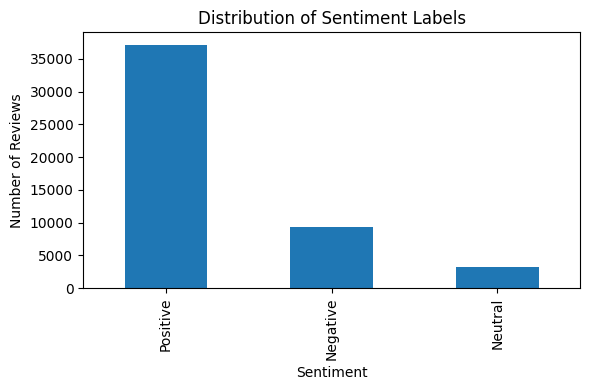

In [11]:
# Count the number of reviews in each sentiment class
sentiment_counts = df["sentiment"].value_counts()

# Display the sentiment counts
print(sentiment_counts)

# Create a bar chart showing the sentiment distribution
plt.figure(figsize=(6, 4))

sentiment_counts.plot(kind="bar")

plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

The dataset contains reviews from three sentiment classes. Positive reviews are the most common, while neutral reviews are the least represented. This imbalance supports RQ2, which investigates how class balancing techniques affect BERT's performance, particularly for the neutral class.

Rating Distribution

This examines the distribution of product ratings in the cleaned dataset. Since the sentiment labels were derived from the review ratings, this visualization helps verify the underlying rating distribution used for sentiment classification.

rating
1     6552
2     2792
3     3271
4     6534
5    30637
Name: count, dtype: int64


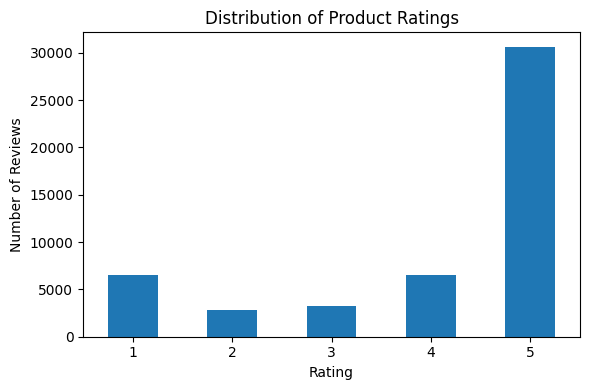

In [12]:
# Count the number of reviews for each rating
rating_counts = df["rating"].value_counts().sort_index()

# Display the rating counts
print(rating_counts)

# Create a bar chart showing the rating distribution
plt.figure(figsize=(6, 4))

rating_counts.plot(kind="bar")

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=360)

plt.tight_layout()
plt.show()

Review Length Analysis

These visualizations examine the distribution of review lengths to understand how much textual information users must process when reading customer reviews. Long and highly variable reviews motivate the need for automatic summarization, which is investigated in RQ1.

In [18]:
# Calculate the length of each review (number of words)
df["review_length"] = df["review"].apply(lambda x: len(str(x).split()))

# Display summary statistics
print(df["review_length"].describe())

# Calculate the 99th percentile of review lengths
# This helps identify the range containing the vast majority of reviews.
review_length_99 = df["review_length"].quantile(0.99)

print("99th percentile:", review_length_99)

count    49786.000000
mean        52.334672
std         81.886095
min          1.000000
25%         13.000000
50%         29.000000
75%         60.000000
max       5945.000000
Name: review_length, dtype: float64
Maximum review length: 5945
99th percentile: 376.0


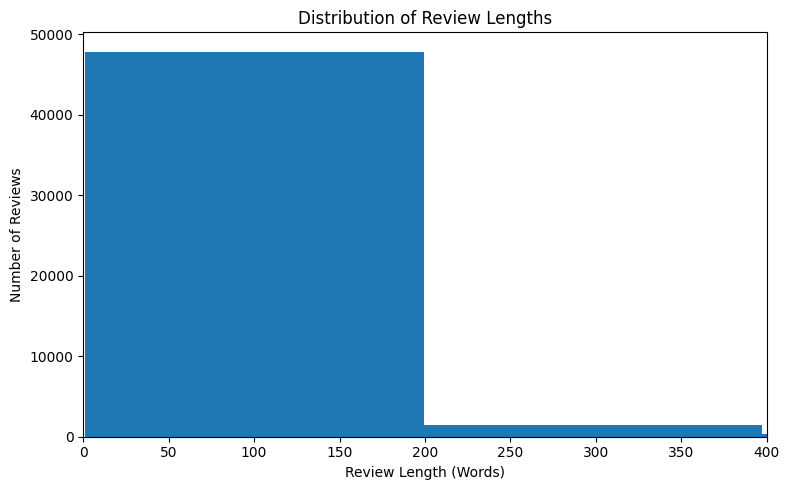

In [19]:
# Plot the distribution of review lengths
plt.figure(figsize=(8, 5))

plt.hist(df["review_length"], bins=30)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (Words)")
plt.ylabel("Number of Reviews")

# The maximum review length is 5,945 words due to a small number of extreme outliers. Since the 99th percentile is approximately 376 words, limiting the x-axis to 400 words allows the histogram to
# clearly display the distribution of nearly all reviews without the outliers compressing the visualization.
plt.xlim(0, 400)

plt.tight_layout()
plt.show()

The histogram shows that review lengths are highly right-skewed, with most reviews containing relatively few words. The x-axis is limited to 400 words because the maximum review length (5,945 words) is caused by a small number of extreme outliers. The 99th percentile of the data is approximately 376 words, meaning that 99% of all reviews contain 376 words or fewer. Limiting the histogram to 400 words improves readability while accurately representing the vast majority of the dataset.

Review Length by Sentiment (Supports Research Question 1)

This visualization compares review lengths across positive, neutral, and negative sentiment categories. Examining review length by sentiment provides additional motivation for automatic review summarization by determining whether consumers may encounter lengthy reviews regardless of the sentiment expressed.

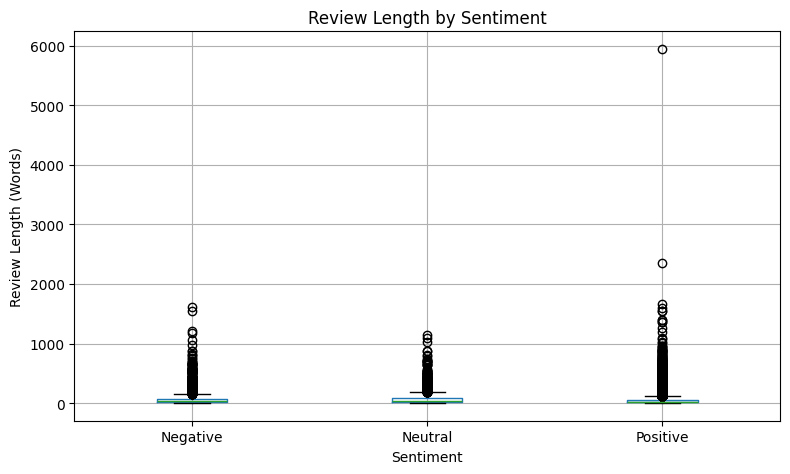

In [24]:
# Create a boxplot comparing review lengths across sentiment categories.
ax = df.boxplot(
    column="review_length",
    by="sentiment",
    figsize=(8,5)
)

# Add a descriptive title and axis labels.
plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Words)")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the plot.
plt.show()

The boxplot compares review lengths across the three sentiment categories while displaying the full range of review lengths. Although most reviews are relatively short, each sentiment category contains numerous extreme outliers, including reviews exceeding 1,000 words and a small number approaching 6,000 words. These outliers demonstrate why the previous histogram was limited to 400 words: the 99th percentile of review lengths is approximately 376 words, meaning that nearly all reviews fall within this range. Limiting the histogram to 400 words improves readability while accurately representing the vast majority of the dataset, whereas the boxplot highlights the presence of the unusually long reviews.

The previous boxplot demonstrates that the dataset contains several extreme outliers. To better compare the distributions of review lengths across sentiment categories, the following visualization limits the y-axis to 400 words, which includes approximately 99% of all reviews.

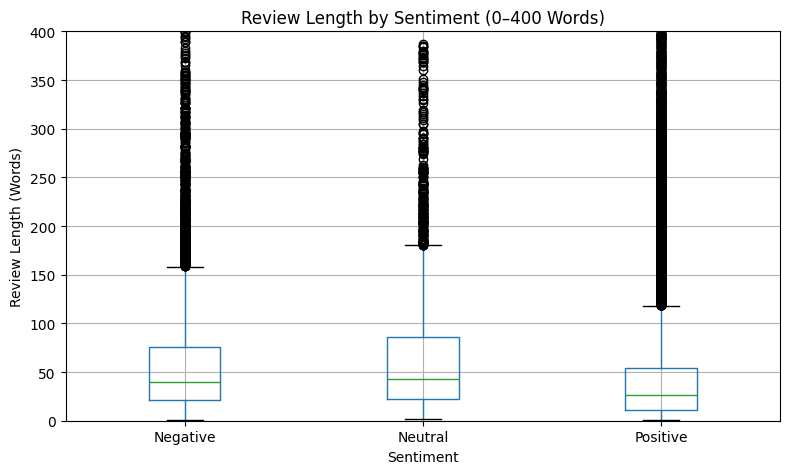

In [25]:
# Create a boxplot comparing review lengths across sentiment categories.
ax = df.boxplot(
    column="review_length",
    by="sentiment",
    figsize=(8,5)
)

# Add a descriptive title and axis labels.
plt.title("Review Length by Sentiment (0–400 Words)")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Words)")

# Limit the y-axis to approximately the 99th percentile of review lengths.
plt.ylim(0, 400)

# Adjust the layout.
plt.tight_layout()

# Display the plot.
plt.show()

The zoomed-in boxplot provides a clearer comparison of review lengths across the three sentiment categories by focusing on reviews between 0 and 400 words, which includes approximately 99% of the dataset. The median review length is slightly higher for neutral reviews than for negative and positive reviews, indicating that neutral reviews tend to be somewhat longer on average. The IQR is also widest for neutral reviews, suggesting greater variability in the middle 50% of review lengths. In contrast, positive reviews have the smallest interquartile range, indicating that their review lengths are more concentrated around the median.

Sentence Count per Review (Supports Research Question 1)

This visualization examines the number of sentences contained in each review. Reviews with more sentences generally require more time and effort to read.

count    49786.000000
mean         5.313060
std          5.818687
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max        369.000000
Name: sentence_count, dtype: float64


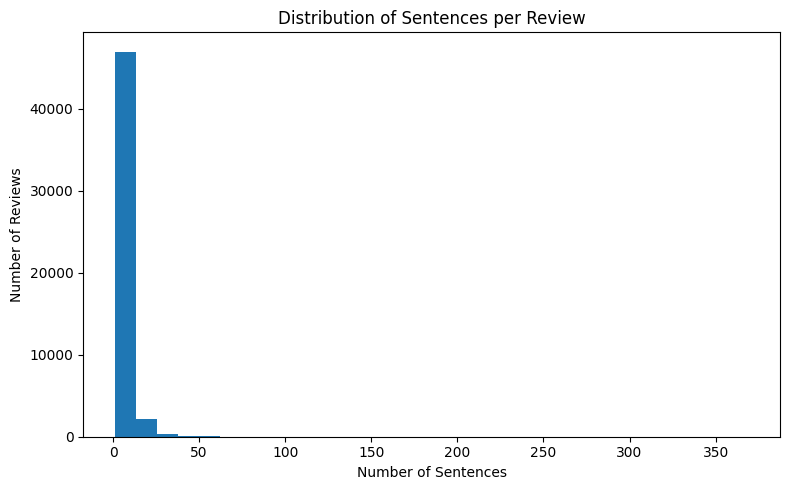

In [26]:
# Estimate the number of sentences in each review by counting periods, question marks, and exclamation points. Reviews with no detected punctuation are assigned a minimum sentence count of one.
df["sentence_count"] = (
    df["review"]
      .astype(str)
      .str.count(r"[.!?]")
      .clip(lower=1)
)

# Display summary statistics for sentence counts.
print(df["sentence_count"].describe())

# Plot the distribution of sentence counts.
plt.figure(figsize=(8,5))

plt.hist(df["sentence_count"], bins=30)

# Add a descriptive title and axis labels.
plt.title("Distribution of Sentences per Review")
plt.xlabel("Number of Sentences")
plt.ylabel("Number of Reviews")

# Adjust the layout.
plt.tight_layout()

# Display the plot.
plt.show()

The histogram shows that the number of sentences per review is heavily right-skewed. Most reviews contain fewer than 10 sentences, indicating that customers typically write relatively concise reviews. However, the distribution also includes a long tail, with a small number of reviews containing substantially more sentences than the majority of the dataset. These longer reviews require more time and effort for consumers to read and understand.

Reviews per Product (Supports Research Question 2)

This visualization examines how many reviews are associated with each product. Products with larger numbers of reviews require more information to be processed during summarization.

count    2287.000000
mean       21.769130
std        79.399932
min         1.000000
25%         3.000000
50%         6.000000
75%        13.000000
max      1422.000000
dtype: float64


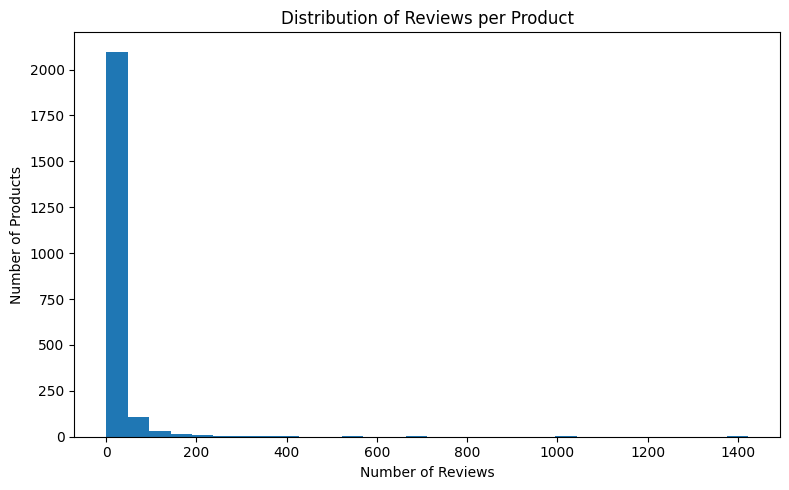

In [27]:
# Count the number of reviews associated with each product.
reviews_per_product = df.groupby("parent_asin").size()

# Display summary statistics.
print(reviews_per_product.describe())

# Plot the distribution.
plt.figure(figsize=(8,5))

plt.hist(reviews_per_product, bins=30)

plt.title("Distribution of Reviews per Product")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Products")

plt.tight_layout()

plt.show()